In [ ]:
# Install
!pip install torch torchvision numpy matplotlib scipy -q
!pip install datasets transformers -q   # HuggingFace — provides IMDB dataset
!pip install adabelief-pytorch -q
print("All packages ready.")


All packages ready.


In [ ]:
import os, math, time, json, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Optimizer
from datetime import datetime
from scipy import stats
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


## IMDB Data Loader

Downloads the IMDB sentiment dataset via HuggingFace `datasets`. Builds a
vocabulary from the training set, tokenises with simple whitespace splitting,
and pads/truncates to a fixed sequence length. No pretrained embeddings — the
model learns embeddings from scratch so the optimizer comparison is fair.


In [ ]:
from datasets import load_dataset
from collections import Counter
import re


# ── Tokeniser ─────────────────────────────────────────────────────────────────

def simple_tokenise(text, max_len=256):
    """Lowercase, strip HTML, split on non-alpha. Truncate to max_len tokens."""
    text = re.sub(r'<[^>]+>', ' ', text.lower())
    tokens = re.findall(r"[a-z']+", text)
    return tokens[:max_len]


class Vocabulary:
    """Maps tokens to integer IDs. Reserves 0=PAD, 1=UNK."""
    PAD, UNK = 0, 1

    def __init__(self, min_freq=3):
        self.min_freq = min_freq
        self.tok2id = {'<PAD>': 0, '<UNK>': 1}
        self.id2tok = {0: '<PAD>', 1: '<UNK>'}

    def build(self, texts):
        counts = Counter(tok for text in texts for tok in simple_tokenise(text))
        for tok, cnt in counts.items():
            if cnt >= self.min_freq and tok not in self.tok2id:
                idx = len(self.tok2id)
                self.tok2id[tok] = idx
                self.id2tok[idx] = tok
        print(f"[vocab] size={len(self.tok2id):,}  "
              f"(min_freq={self.min_freq}, {sum(1 for c in counts.values() if c < self.min_freq):,} rare tokens dropped)")
        return self

    def encode(self, text, max_len=256):
        tokens = simple_tokenise(text, max_len)
        return [self.tok2id.get(t, self.UNK) for t in tokens]

    def __len__(self):
        return len(self.tok2id)


# ── Dataset ────────────────────────────────────────────────────────────────────

class IMDBDataset(Dataset):
    def __init__(self, hf_split, vocab, max_len=256):
        self.vocab   = vocab
        self.max_len = max_len
        self.texts   = [x['text']  for x in hf_split]
        self.labels  = [x['label'] for x in hf_split]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = self.vocab.encode(self.texts[idx], self.max_len)
        ids = ids + [Vocabulary.PAD] * (self.max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


def get_imdb_loaders(batch_size=64, max_len=256, val_split=0.1,
                     min_freq=3, num_workers=2, seed=42):
    print("[data] Downloading IMDB from HuggingFace...")
    raw = load_dataset('imdb')
    vocab = Vocabulary(min_freq=min_freq).build(raw['train']['text'])
    train_ds = IMDBDataset(raw['train'], vocab, max_len)
    test_ds  = IMDBDataset(raw['test'],  vocab, max_len)
    n_val   = int(len(train_ds) * val_split)
    n_train = len(train_ds) - n_val
    generator = torch.Generator().manual_seed(seed)
    train_sub, val_sub = random_split(train_ds, [n_train, n_val], generator=generator)
    train_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_sub,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    print(f"[data] Train: {n_train:,}  Val: {n_val:,}  Test: {len(test_ds):,}")
    print(f"[data] Vocab size: {len(vocab):,}  Max seq len: {max_len}")
    return train_loader, val_loader, test_loader, vocab


# ── Quick smoke test ───────────────────────────────────────────────────────────
_tl, _vl, _tel, _vocab = get_imdb_loaders(batch_size=4, num_workers=0, seed=0)
_ids, _lbls = next(iter(_tl))
assert _ids.shape  == (4, 256), f"Expected (4,256), got {_ids.shape}"
assert _lbls.max() <= 1
print(f"Loader OK — batch {list(_ids.shape)}, labels {_lbls.tolist()}")
del _tl, _vl, _tel


[data] Downloading IMDB from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

[vocab] size=34,907  (min_freq=3, 40,858 rare tokens dropped)
[data] Train: 22,500  Val: 2,500  Test: 25,000
[data] Vocab size: 34,907  Max seq len: 256
Loader OK — batch [4, 256], labels [1, 0, 0, 1]


## Model — LSTM with Attention


In [ ]:
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=True)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out, mask=None):
        energy  = self.v(torch.tanh(self.W(lstm_out))).squeeze(-1)
        if mask is not None:
            energy = energy.masked_fill(mask == 0, float('-inf'))
        weights = F.softmax(energy, dim=1)
        context = (weights.unsqueeze(-1) * lstm_out).sum(dim=1)
        return context, weights


class LSTMAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 n_layers=2, num_classes=2, embed_dropout=0.3,
                 fc_dropout=0.4, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                            bidirectional=True,
                            dropout=0.3 if n_layers > 1 else 0.0,
                            batch_first=True)
        self.attention  = AttentionLayer(hidden_dim * 2)
        self.drop       = nn.Dropout(fc_dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.ReLU(),
            nn.Dropout(fc_dropout), nn.Linear(64, num_classes))

    def forward(self, x):
        mask   = (x != 0)
        emb    = self.drop(self.embedding(x))
        out, _ = self.lstm(emb)
        ctx, _ = self.attention(out, mask)
        return self.classifier(self.drop(ctx))


# sanity check
_model = LSTMAttentionClassifier(len(_vocab))
_x     = torch.zeros(4, 256, dtype=torch.long)
_out   = _model(_x)
assert _out.shape == (4, 2)
n_params = sum(p.numel() for p in _model.parameters())
print(f"LSTMAttentionClassifier: {n_params/1e6:.2f}M params, output {_out.shape}")
del _model, _x, _out


LSTMAttentionClassifier: 5.21M params, output torch.Size([4, 2])


## PhaseAwareOptimizer


In [ ]:
from torch.optim import Optimizer
import math


class PhaseAwareOptimizer(Optimizer):
    """
    Phase-Aware Optimizer v5 — Flat-Minima Edition.

    Key fixes over v4 (based on empirical results showing sharp minima):

    1. NOISE FLOOR (noise_min > 0)
       v4 let noise decay to ~0 by phi=0.9 → model locked into sharp basins.
       v5 keeps noise >= noise_min throughout. This maintains gentle exploration
       pressure in late training, preventing the optimizer from getting stuck
       in narrow valleys that don't generalise.

    2. SAM-LITE (sharpness-aware gradient correction)
       Before the Adam update, we add a small gradient perturbation:
           g_corrected = g + sam_coeff * g / (||g|| + eps)
       This is a single forward-pass approximation of SAM's perturbation step.
       It biases the update direction AWAY from sharp curvature without
       requiring a second backward pass (2x cost of full SAM).
       sam_coeff decays with phi so it's strong early, gentle late.

    3. DECOUPLED WEIGHT DECAY (AdamW-style)
       v4 added weight_decay into the gradient (L2 regularisation).
       That couples regularisation with the adaptive scaling, which
       distorts the update direction. v5 applies weight decay directly
       to parameters AFTER the Adam step, identical to AdamW.
       This is the single biggest reason AdamW beats Adam on generalisation.

    4. DYNAMIC PHASE using loss plateau detection
       phi now incorporates a loss-plateau signal:
       when val loss stops improving, phi is nudged upward faster,
       triggering earlier stabilisation. This makes the optimizer
       genuinely adaptive rather than just time-scheduled.

    5. MOMENTUM SCHEDULE (β1 peaks mid-training)
       Fixed β1 is suboptimal. v5 uses:
           β1(phi) = β1_min + (β1_max - β1_min) * sin(pi * phi)
       β1_min early (exploration, don't lock direction too early)
       β1_max mid   (stabilise trajectory when loss is dropping fast)
       β1_min late  (fine-tune, allow local adjustments)
    """

    def __init__(self, params,
                 # LR schedule
                 lr_max=0.001, lr_min=2e-5,
                 warmup_ratio=0.03, hold_frac=0.12,
                 # Adam core
                 beta1=0.9, beta1_max=0.95,
                 beta2=0.999, eps=1e-8,
                 # Noise (v5: floor prevents sharp minima)
                 noise_max=0.04, noise_min=0.008,
                 # SAM-lite (sharpness correction)
                 sam_coeff=0.015,
                 # Regularisation (decoupled)
                 weight_decay=0.01,
                 # Training control
                 total_steps=10000, max_grad_norm=1.0,
                 # Phase type
                 phase_type='adaptive',
                 var_window=50, time_weight=0.7):

        defaults = dict(
            lr_max=lr_max, lr_min=lr_min,
            warmup_ratio=warmup_ratio, hold_frac=hold_frac,
            beta1=beta1, beta1_max=beta1_max,
            beta2=beta2, eps=eps,
            noise_max=noise_max, noise_min=noise_min,
            sam_coeff=sam_coeff,
            weight_decay=weight_decay,
            total_steps=total_steps, max_grad_norm=max_grad_norm,
            phase_type=phase_type,
            var_window=var_window, time_weight=time_weight,
        )
        super().__init__(params, defaults)
        self.step_count         = 0
        self.phase              = 0.0
        self.current_lr         = 0.0
        self.current_noise      = 0.0
        self._grad_norm_history = []
        self._initial_var       = None
        self._loss_history      = []   # for plateau detection

    # ── Phase variable ────────────────────────────────────────────────────
    def _phi_time(self):
        return min(1.0, self.step_count / max(1, self.defaults['total_steps']))

    def _phi(self, avg_grad_norm):
        phi_t = self._phi_time()
        if self.defaults['phase_type'] == 'time':
            return phi_t

        # Gradient variance component (original)
        w = self.defaults['var_window']
        self._grad_norm_history.append(avg_grad_norm)
        if len(self._grad_norm_history) > w * 4:
            self._grad_norm_history = self._grad_norm_history[-w * 2:]
        if len(self._grad_norm_history) < w:
            return phi_t
        recent   = self._grad_norm_history[-w:]
        mean_r   = sum(recent) / w
        var_now  = sum((x - mean_r) ** 2 for x in recent) / w
        if self._initial_var is None:
            self._initial_var = max(var_now, 1e-12)
        norm_var = min(1.0, var_now / max(self._initial_var, 1e-12))

        # Loss plateau component: if loss stopped improving, push phi higher
        # (signals: time to switch from exploration to convergence)
        plateau_signal = 0.0
        if len(self._loss_history) >= 2 * w:
            recent_loss = self._loss_history[-w:]
            older_loss  = self._loss_history[-2*w:-w]
            mean_recent = sum(recent_loss) / w
            mean_older  = sum(older_loss) / w
            # If recent loss is not improving much, plateau_signal → 1
            relative_improvement = max(0.0, (mean_older - mean_recent) / max(mean_older, 1e-8))
            plateau_signal = max(0.0, 1.0 - relative_improvement * 20.0)

        tw = self.defaults['time_weight']
        # Combine: time + variance stabilisation + plateau
        phi_dynamic = (tw * phi_t
                       + 0.15 * (1.0 - norm_var)
                       + 0.15 * plateau_signal)
        return min(1.0, max(phi_t, phi_dynamic))

    def log_loss(self, loss_val):
        """Call each step with the current batch loss for plateau detection."""
        self._loss_history.append(loss_val)
        if len(self._loss_history) > 200:
            self._loss_history = self._loss_history[-100:]

    # ── LR schedule ──────────────────────────────────────────────────────
    def _lr(self, phi):
        """
        warmup → plateau at lr_max → cosine decay to lr_min
        Stage boundaries controlled by warmup_ratio and hold_frac.
        """
        d  = self.defaults
        wr = d['warmup_ratio']
        hr = wr + d['hold_frac']
        if phi < wr:
            return d['lr_max'] * (phi / max(wr, 1e-8))
        if phi < hr:
            return d['lr_max']
        adj = (phi - hr) / max(1.0 - hr, 1e-8)
        return d['lr_min'] + 0.5 * (d['lr_max'] - d['lr_min']) * (1.0 + math.cos(math.pi * adj))

    # ── β1 schedule ───────────────────────────────────────────────────────
    def _beta1(self, phi):
        """
        β1 follows a sine arch: starts at beta1, peaks at beta1_max mid-training,
        returns to beta1 at end. This gives:
          early:  moderate momentum (don't lock direction too early)
          mid:    strong momentum   (stabilise trajectory when loss drops fast)
          late:   moderate momentum (allow fine-grained local adjustments)
        """
        d = self.defaults
        b_min = d['beta1']
        b_max = d['beta1_max']
        return b_min + (b_max - b_min) * math.sin(math.pi * phi)

    # ── Noise (v5: floor — never zero) ───────────────────────────────────
    def _noise_scale(self, phi, rms_u):
        """
        v4: noise → 0 at end → sharp minima
        v5: noise → noise_min at end → gentle late-training flatness pressure
        Linear decay from noise_max to noise_min, scaled by RMS of update.
        """
        d = self.defaults
        frac = d['noise_min'] + (d['noise_max'] - d['noise_min']) * (1.0 - phi)
        return frac * rms_u

    # ── Cauchy noise ──────────────────────────────────────────────────────
    def _cauchy(self, shape, device):
        u = torch.rand(shape, device=device) - 0.5
        return torch.clamp(torch.tan(math.pi * u), -3.0, 3.0)

    # ── Main step ─────────────────────────────────────────────────────────
    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        self.step_count += 1
        d = self.defaults

        # ── Gradient clipping ─────────────────────────────────────────────
        raw_norms = [p.grad.norm().item()
                     for g in self.param_groups
                     for p in g['params'] if p.grad is not None]
        avg_grad_norm = sum(raw_norms) / max(len(raw_norms), 1)
        if d['max_grad_norm'] > 0:
            all_p = [p for g in self.param_groups for p in g['params']
                     if p.grad is not None]
            torch.nn.utils.clip_grad_norm_(all_p, d['max_grad_norm'])

        # ── Phase, LR, β1 ─────────────────────────────────────────────────
        phi = self._phi(avg_grad_norm)
        lr  = self._lr(phi)
        b1  = self._beta1(phi)
        self.phase, self.current_lr = phi, lr

        b2, eps = d['beta2'], d['eps']
        t       = self.step_count
        bc1     = 1.0 - b1 ** t   # bias correction — recomputed each step since b1 changes
        bc2     = 1.0 - b2 ** t

        # SAM-lite coefficient: strong early, fades with phase
        sam_c = d['sam_coeff'] * (1.0 - phi * 0.8)   # 100%→20% of sam_coeff

        noise_log = 0.0

        for group in self.param_groups:
            wd = group['weight_decay']
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad.data

                # ── SAM-lite: sharpness-aware gradient correction ──────────
                # Adds a small perturbation in the gradient direction,
                # scaled by sam_c / (||g|| + eps).
                # Effect: pushes update away from sharp curvature.
                # Single-pass (no extra forward/backward needed).
                if sam_c > 1e-8:
                    g_norm = grad.norm().add_(eps)
                    grad = grad + sam_c * grad / g_norm

                # ── Adam moment updates ────────────────────────────────────
                state = self.state[p]
                if len(state) == 0:
                    state['step'] = 0
                    state['m']    = torch.zeros_like(p)
                    state['v']    = torch.zeros_like(p)

                m, v = state['m'], state['v']
                m.mul_(b1).add_(grad, alpha=1.0 - b1)
                v.mul_(b2).addcmul_(grad, grad, value=1.0 - b2)

                m_hat = m / bc1
                v_hat = v / bc2
                u_hat = m_hat / v_hat.sqrt().add_(eps)

                # ── Adam parameter update ──────────────────────────────────
                p.data.add_(u_hat, alpha=-lr)

                # ── Decoupled weight decay (AdamW-style) ──────────────────
                # Applied AFTER Adam step, not inside gradient.
                # This is why AdamW beats Adam: the decay is not distorted
                # by the adaptive scaling of v_hat.
                if wd != 0.0:
                    p.data.mul_(1.0 - lr * wd)

                # ── Cauchy tunneling noise (v5: floor prevents dying) ──────
                n_elem     = u_hat.numel()
                rms_u      = u_hat.norm().item() / math.sqrt(max(n_elem, 1))
                noise_scale = self._noise_scale(phi, rms_u)
                noise_log   = noise_scale
                if noise_scale > 1e-12:
                    xi = self._cauchy(p.data.shape, p.data.device)
                    p.data.add_(xi, alpha=lr * noise_scale)

                state['step'] += 1

        self.current_noise = lr * noise_log
        return loss

    def get_current_state(self):
        return {
            'phase': self.phase,
            'lr':    self.current_lr,
            'noise': self.current_noise,
            'step':  self.step_count,
        }


print("PhaseAwareOptimizer v5 defined.")
print("  Changes vs v4:")
print("  [1] noise_min floor — prevents sharp minima trapping")
print("  [2] SAM-lite — sharpness-aware correction, no extra backward pass")
print("  [3] Decoupled weight decay (AdamW-style) — biggest generalisation fix")
print("  [4] Dynamic phi with loss plateau signal")
print("  [5] beta1 schedule: sine arch (medium -> high -> medium)")


PhaseAwareOptimizer v5 defined.
  Changes vs v4:
  [1] noise_min floor — prevents sharp minima trapping
  [2] SAM-lite — sharpness-aware correction, no extra backward pass
  [3] Decoupled weight decay (AdamW-style) — biggest generalisation fix
  [4] Dynamic phi with loss plateau signal
  [5] beta1 schedule: sine arch (medium -> high -> medium)


## Baseline Optimizers


In [ ]:
import torch
import torch.optim as optim
import math


class AdaBelief(optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-16,
                 weight_decay=0.0, max_grad_norm=0.0):
        defaults = dict(lr=lr, betas=betas, eps=eps,
                        weight_decay=weight_decay, max_grad_norm=max_grad_norm)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad(): loss = closure()
        max_norm = self.defaults['max_grad_norm']
        if max_norm > 0:
            all_p = [p for g in self.param_groups for p in g['params'] if p.grad is not None]
            torch.nn.utils.clip_grad_norm_(all_p, max_norm)
        for group in self.param_groups:
            b1, b2 = group['betas']
            eps, lr, wd = group['eps'], group['lr'], group['weight_decay']
            for p in group['params']:
                if p.grad is None: continue
                g = p.grad.data
                if wd != 0: g = g.add(p.data, alpha=wd)
                st = self.state[p]
                if len(st) == 0:
                    st['step'] = 0
                    st['m'] = torch.zeros_like(p)
                    st['s'] = torch.zeros_like(p)
                st['step'] += 1
                t, m, s = st['step'], st['m'], st['s']
                m.mul_(b1).add_(g, alpha=1 - b1)
                surprise = (g - m).pow(2).add_(eps)
                s.mul_(b2).add_(surprise, alpha=1 - b2)
                m_hat = m / (1 - b1**t)
                s_hat = s / (1 - b2**t)
                p.data.addcdiv_(m_hat, s_hat.sqrt().add_(eps), value=-lr)
        return loss


class SAM(optim.Optimizer):
    def __init__(self, params, base_optimizer_cls, rho=0.05, **base_kwargs):
        defaults = dict(rho=rho)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer_cls(self.param_groups, **base_kwargs)
        self.param_groups   = self.base_optimizer.param_groups
        self.rho = rho

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None: continue
                self.state[p]['old_p'] = p.data.clone()
                p.data.add_(p.grad, alpha=scale)
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                p.data = self.state[p]['old_p']
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    def step(self, closure=None):
        raise NotImplementedError("Use first_step / second_step")

    def _grad_norm(self):
        norms = [p.grad.norm(2) for g in self.param_groups
                 for p in g['params'] if p.grad is not None]
        return torch.stack(norms).norm(2)


class Lion(optim.Optimizer):
    def __init__(self, params, lr=1e-4, betas=(0.9, 0.99),
                 weight_decay=0.0, max_grad_norm=0.0):
        defaults = dict(lr=lr, betas=betas, weight_decay=weight_decay,
                        max_grad_norm=max_grad_norm)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad(): loss = closure()
        max_norm = self.defaults['max_grad_norm']
        if max_norm > 0:
            all_p = [p for g in self.param_groups for p in g['params'] if p.grad is not None]
            torch.nn.utils.clip_grad_norm_(all_p, max_norm)
        for group in self.param_groups:
            b1, b2 = group['betas']
            lr, wd = group['lr'], group['weight_decay']
            for p in group['params']:
                if p.grad is None: continue
                g = p.grad.data
                st = self.state[p]
                if len(st) == 0:
                    st['m'] = torch.zeros_like(p)
                m = st['m']
                c = b1 * m + (1 - b1) * g
                p.data.add_(torch.sign(c) + wd * p.data, alpha=-lr)
                m.mul_(b2).add_(g, alpha=1 - b2)
        return loss


print("AdaBelief / SAM / Lion defined.")


AdaBelief / SAM / Lion defined.


## Training Loop & Dynamics Logger


In [ ]:
class DynamicsLogger:
    """
    Records per-step optimization signals during training.

    Per step:  train_loss, grad_norm (pre-clip), update_norm (||Delta theta||),
               lr, phase (phi), noise_magnitude.
    Per epoch: aggregated means/stds of the above + val metrics.
    """
    def __init__(self):
        self.steps  = []   # one dict per optimizer step
        self.epochs = []   # one dict per epoch (aggregated)
        self._buf   = []   # accumulator for current epoch

    def log_step(self, d):
        self.steps.append(d)
        self._buf.append(d)

    def end_epoch(self, val_loss, val_acc, train_acc):
        if not self._buf:
            return
        def _m(key): return float(np.mean([s[key] for s in self._buf]))
        def _s(key): return float(np.std([s[key]  for s in self._buf]))
        phases = [s['phase'] for s in self._buf if not np.isnan(s['phase'])]
        self.epochs.append({
            'train_loss_mean':    _m('train_loss'),
            'loss_oscillation':   _s('train_loss'),
            'grad_norm_mean':     _m('grad_norm'),
            'grad_norm_var':      float(np.var([s['grad_norm'] for s in self._buf])),
            'update_norm_mean':   _m('update_norm'),
            'lr_mean':            _m('lr'),
            'noise_mean':         _m('noise_magnitude'),
            'phase_mean':         float(np.mean(phases)) if phases else float('nan'),
            'val_loss':           val_loss,
            'val_acc':            val_acc,
            'train_acc':          train_acc,
        })
        self._buf = []

    def summary(self):
        if not self.steps: return {}
        gnorms = [s['grad_norm'] for s in self.steps]
        losses = [s['train_loss'] for s in self.steps]
        return {
            'total_steps':       len(self.steps),
            'mean_grad_norm':    float(np.mean(gnorms)),
            'grad_norm_var':     float(np.var(gnorms)),
            'loss_oscillation':  float(np.std(losses)),
        }


print("DynamicsLogger defined.")


DynamicsLogger defined.


In [ ]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _global_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.data.norm(2).item() ** 2
    return total ** 0.5


def train_epoch_nlp(model, loader, optimizer, criterion, device, logger=None):
    """One training epoch. SAM-aware. Logs dynamics if logger supplied."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    is_sam = isinstance(optimizer, SAM)

    for ids, labels in loader:
        ids, labels = ids.to(device), labels.to(device)

        # snapshot params before step to compute update norm
        if logger is not None:
            params_before = torch.cat([p.data.view(-1) for p in model.parameters()]).clone()

        if is_sam:
            optimizer.zero_grad()
            out  = model(ids)
            loss = criterion(out, labels)
            loss.backward()
            if logger is not None:
                gn = _global_grad_norm(model)
            optimizer.first_step(zero_grad=True)
            criterion(model(ids), labels).backward()
            optimizer.second_step(zero_grad=True)
        else:
            optimizer.zero_grad()
            out  = model(ids)
            loss = criterion(out, labels)
            loss.backward()
            if logger is not None:
                gn = _global_grad_norm(model)
            optimizer.step()
            # v5: feed loss to optimizer for plateau detection
            if hasattr(optimizer, 'log_loss'):
                optimizer.log_loss(loss.item())

        total_loss += loss.item() * ids.size(0)
        correct    += out.argmax(1).eq(labels).sum().item()
        total      += ids.size(0)

        if logger is not None:
            params_after = torch.cat([p.data.view(-1) for p in model.parameters()])
            update_norm  = (params_after - params_before).norm(2).item()
            phase, lr_now, noise_mag = float('nan'), float('nan'), 0.0
            if hasattr(optimizer, 'get_current_state'):
                s = optimizer.get_current_state()
                phase, lr_now, noise_mag = s['phase'], s['lr'], s['noise']
            elif hasattr(optimizer, 'param_groups'):
                lr_now = optimizer.param_groups[0]['lr']
                phase  = float('nan')
            logger.log_step({'train_loss': loss.item(), 'grad_norm': gn,
                             'update_norm': update_norm, 'phase': phase,
                             'lr': lr_now, 'noise_magnitude': noise_mag})

    return total_loss / total, 100.0 * correct / total


def eval_epoch_nlp(model, loader, criterion, device):
    """One validation/test pass."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for ids, labels in loader:
            ids, labels = ids.to(device), labels.to(device)
            out         = model(ids)
            loss        = criterion(out, labels)
            total_loss += loss.item() * ids.size(0)
            correct    += out.argmax(1).eq(labels).sum().item()
            total      += ids.size(0)
    return total_loss / total, 100.0 * correct / total


def build_optimizer_nlp(opt_cfg, model, total_steps):
    name = opt_cfg['name']
    p    = model.parameters()
    wd   = opt_cfg.get('weight_decay', 1e-4)
    if name == 'phase_aware':
        return PhaseAwareOptimizer(
            p,
            lr_max        = opt_cfg['lr_max'],
            lr_min        = opt_cfg.get('lr_min',        2e-5),
            warmup_ratio  = opt_cfg.get('warmup_ratio',  0.03),
            hold_frac     = opt_cfg.get('hold_frac',     0.12),
            beta1         = opt_cfg.get('beta1',         0.9),
            beta1_max     = opt_cfg.get('beta1_max',     0.95),
            beta2         = opt_cfg.get('beta2',         0.999),
            noise_max     = opt_cfg.get('noise_max',     0.04),
            noise_min     = opt_cfg.get('noise_min',     0.008),
            sam_coeff     = opt_cfg.get('sam_coeff',     0.015),
            weight_decay  = wd,
            total_steps   = total_steps,
            max_grad_norm = opt_cfg.get('max_grad_norm', 1.0),
            phase_type    = opt_cfg.get('phase_type',    'adaptive'),
            var_window    = opt_cfg.get('var_window',    50),
            time_weight   = opt_cfg.get('time_weight',   0.7),
        )
    elif name == 'adam':
        return optim.Adam(p, lr=opt_cfg['lr'], weight_decay=wd)
    elif name == 'adamw':
        return optim.AdamW(p, lr=opt_cfg['lr'], weight_decay=opt_cfg.get('weight_decay', 1e-2))
    elif name == 'radam':
        return optim.RAdam(p, lr=opt_cfg['lr'], weight_decay=wd)
    elif name == 'adabelief':
        return AdaBelief(p, lr=opt_cfg['lr'], weight_decay=wd,
                         max_grad_norm=opt_cfg.get('max_grad_norm', 1.0))
    elif name == 'sgd':
        return optim.SGD(p, lr=opt_cfg['lr'],
                         momentum=opt_cfg.get('momentum', 0.9), weight_decay=wd)
    elif name == 'lion':
        return Lion(p, lr=opt_cfg['lr'], weight_decay=opt_cfg.get('weight_decay', 1e-2),
                    max_grad_norm=opt_cfg.get('max_grad_norm', 1.0))
    elif name == 'sam':
        return SAM(p, optim.SGD, rho=opt_cfg.get('rho', 0.05),
                   lr=opt_cfg['lr'], momentum=opt_cfg.get('momentum', 0.9),
                   weight_decay=wd)
    raise ValueError(f"Unknown optimizer: {name}")


def run_single_nlp(opt_cfg, seed, cfg, vocab):
    """Train one optimizer x one seed. Returns result dict with full dynamics."""
    set_seed(seed)
    train_loader, val_loader, test_loader, _ = get_imdb_loaders(
        batch_size=cfg['batch_size'], max_len=cfg['max_len'],
        num_workers=cfg.get('num_workers', 2), seed=seed)
    model = LSTMAttentionClassifier(
        vocab_size=len(vocab), embed_dim=cfg.get('embed_dim', 128),
        hidden_dim=cfg.get('hidden_dim', 128), n_layers=cfg.get('n_layers', 2)
    ).to(device)
    epochs      = cfg['epochs']
    total_steps = len(train_loader) * epochs
    optimizer   = build_optimizer_nlp(opt_cfg, model, total_steps)
    criterion   = nn.CrossEntropyLoss()
    logger      = DynamicsLogger()
    opt_name    = opt_cfg['name']
    print(f"\n  [seed={seed}] {opt_name:12} | steps={total_steps} | device={device}")
    history  = {'train_losses': [], 'train_accs': [], 'val_losses': [], 'val_accs': []}
    best_val = 0.0
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch_nlp(model, train_loader, optimizer,
                                          criterion, device, logger)
        vl_loss, vl_acc = eval_epoch_nlp(model, val_loader, criterion, device)
        history['train_losses'].append(tr_loss)
        history['train_accs'].append(tr_acc)
        history['val_losses'].append(vl_loss)
        history['val_accs'].append(vl_acc)
        best_val = max(best_val, vl_acc)
        logger.end_epoch(vl_loss, vl_acc, tr_acc)
        phase_str = ''
        if hasattr(optimizer, 'get_current_state'):
            s = optimizer.get_current_state()
            phase_str = f"  phi={s['phase']:.2f} lr={s['lr']:.5f} noise={s['noise']:.1e}"
        print(f"    Epoch {epoch:>2}/{epochs}  loss={tr_loss:.4f}  "
              f"train={tr_acc:.1f}%  val={vl_acc:.1f}%  ({time.time()-t0:.0f}s){phase_str}")
    te_loss, te_acc = eval_epoch_nlp(model, test_loader, criterion, device)
    print(f"    Test accuracy: {te_acc:.2f}%")
    # convergence speed: first epoch reaching 80% val acc
    conv_ep = next((i+1 for i, a in enumerate(history['val_accs']) if a >= 80.0), epochs)
    return {
        'seed':             seed,
        'final_acc':        history['val_accs'][-1],
        'best_acc':         best_val,
        'test_acc':         te_acc,
        'history':          history,
        'logger':           logger,
        'convergence_ep':   conv_ep,
        'dynamics_summary': logger.summary(),
        'model_state':      {k: v.cpu().clone() for k, v in model.state_dict().items()},
    }


print("Training functions defined.")


Training functions defined.


## Perturbation Robustness Test (Loss Landscape Flatness)


In [ ]:
def perturbation_robustness(model_state_dict, vocab, cfg, test_loader,
                             criterion, device,
                             sigmas=None, n_samples=5):
    """
    Perturb weights theta -> theta + N(0, sigma) and measure Δloss.
    Lower Δloss at a given sigma = flatter minimum = better generalisation.

    Returns dict {sigma: mean_delta_loss}.
    """
    if sigmas is None:
        sigmas = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

    def _make_model():
        m = LSTMAttentionClassifier(
            vocab_size=len(vocab), embed_dim=cfg.get('embed_dim', 128),
            hidden_dim=cfg.get('hidden_dim', 128), n_layers=cfg.get('n_layers', 2)
        ).to(device)
        m.load_state_dict({k: v.to(device) for k, v in model_state_dict.items()})
        return m

    # baseline loss with clean weights
    base_model = _make_model()
    base_loss, _ = eval_epoch_nlp(base_model, test_loader, criterion, device)
    del base_model

    results = {}
    for sigma in sigmas:
        if sigma == 0.0:
            results[sigma] = 0.0
            continue
        deltas = []
        for _ in range(n_samples):
            m = _make_model()
            with torch.no_grad():
                for p in m.parameters():
                    p.data.add_(torch.randn_like(p) * sigma)
            noisy_loss, _ = eval_epoch_nlp(m, test_loader, criterion, device)
            deltas.append(noisy_loss - base_loss)
            del m
        results[sigma] = float(np.mean(deltas))
    return results


print("perturbation_robustness defined.")


perturbation_robustness defined.


## Experiment Configuration & Run


In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
IMDB_CFG = {
    'batch_size':  64,
    'max_len':     256,
    'epochs':      20,   # extended: PA finds flat minima but needs more epochs
    'embed_dim':   128,
    'hidden_dim':  128,
    'n_layers':    2,
    'num_workers': 2,
}

OPTIMIZERS_CFG = [
    {
        'name': 'phase_aware',
        #
        # PhaseAware v5 — Flat-Minima Edition
        # Based on empirical diagnosis of v4 results (test=85.76-87.74%):
        #
        # ROOT CAUSE of v4 failure:
        #   - perturb=0.0044-0.0485 (highest) → sharp minima (BAD for generalisation)
        #   - noise decayed to ~0 by ep18 → nothing pushing away from sharp basins
        #   - weight_decay was grad-coupled (Adam L2) not decoupled (AdamW-style)
        #   - fixed β1=0.9 too rigid: either too strong early or too weak mid
        #
        # v5 FIXES:
        #   [1] noise_min=0.008 → noise never dies, always gentle flatness pressure
        #   [2] sam_coeff=0.015 → SAM-lite correction, biases away from sharp valleys
        #   [3] weight_decay=0.01 decoupled (AdamW-style) → biggest generalisation fix
        #   [4] beta1/beta1_max → sine-arch schedule: grows mid, drops late
        #   [5] phase_type='adaptive' → phi responds to gradient variance + loss plateau
        #
        # LR schedule
        'lr_max':       0.0016,   # matched to RAdam's effective step size
        'lr_min':       2e-5,     # clean cosine completion
        'warmup_ratio': 0.03,     # ~0.6 epoch warmup (was 0.9, now fast like RAdam)
        'hold_frac':    0.12,     # 12% plateau = 2.4 epochs at peak LR
        # Momentum
        'beta1':        0.9,      # starting β1 (moderate — don't lock direction early)
        'beta1_max':    0.95,     # peak β1 at mid-training (strong directional stability)
        # Noise — v5: noise_min > 0 is the key fix
        'noise_max':    0.04,     # early exploration strength
        'noise_min':    0.008,    # late-training floor — 20% of max, never zero
        # SAM-lite sharpness correction
        'sam_coeff':    0.015,    # gradient perturbation strength (decays with phi)
        # Regularisation — decoupled (AdamW-style)
        'weight_decay': 0.01,     # strong enough to bias toward flat minima
        'max_grad_norm': 1.0,
        # Phase control
        'phase_type':   'adaptive',  # uses grad variance + loss plateau signal
        'var_window':   50,
        'time_weight':  0.7,
    },
    {'name': 'adam',      'lr': 0.001, 'weight_decay': 1e-4},
    {'name': 'adamw',     'lr': 0.001, 'weight_decay': 1e-2},
    {'name': 'radam',     'lr': 0.001, 'weight_decay': 1e-4},
    {'name': 'adabelief', 'lr': 0.001, 'weight_decay': 1e-4, 'max_grad_norm': 1.0},
    {'name': 'lion',      'lr': 1e-4,  'weight_decay': 1e-2, 'max_grad_norm': 1.0},
    {'name': 'sgd',       'lr': 0.01,  'momentum': 0.9, 'weight_decay': 1e-4},
    # {'name': 'sam', 'lr': 0.01, 'momentum': 0.9, 'weight_decay': 1e-4, 'rho': 0.05},
]

N_SEEDS = 5
SEEDS   = list(range(N_SEEDS))

# ── Load shared vocab ──────────────────────────────────────────────────────────
_, _, _, VOCAB = get_imdb_loaders(
    batch_size=4, max_len=IMDB_CFG['max_len'], num_workers=0, seed=0)

# ── Main training loop ─────────────────────────────────────────────────────────
all_results = {}

for opt_cfg in OPTIMIZERS_CFG:
    name = opt_cfg['name']
    print(f"\n{'='*60}")
    print(f"  Optimizer: {name}")
    print(f"{'='*60}")
    runs = []
    for seed in SEEDS:
        result = run_single_nlp(opt_cfg, seed, IMDB_CFG, VOCAB)
        runs.append(result)
    val_accs  = [r['final_acc'] for r in runs]
    test_accs = [r['test_acc']  for r in runs]
    best_accs = [r['best_acc']  for r in runs]
    print(f"\n  [{name}]  "
          f"val={np.mean(val_accs):.2f}+/-{np.std(val_accs):.2f}%  "
          f"test={np.mean(test_accs):.2f}+/-{np.std(test_accs):.2f}%  "
          f"best={np.mean(best_accs):.2f}+/-{np.std(best_accs):.2f}%")
    all_results[name] = runs

# ── Run perturbation robustness on best seed per optimizer ─────────────────────
print("\nRunning perturbation robustness tests (this takes a few minutes)...")
_, _, shared_test_loader, _ = get_imdb_loaders(
    batch_size=64, max_len=IMDB_CFG['max_len'], num_workers=0, seed=0)
shared_criterion = nn.CrossEntropyLoss()

perturb_results = {}
for name, runs in all_results.items():
    best_run = max(runs, key=lambda r: r['best_acc'])
    perturb_results[name] = perturbation_robustness(
        best_run['model_state'], VOCAB, IMDB_CFG,
        shared_test_loader, shared_criterion, device)
    print(f"  {name}: done")

# ── Build summary ──────────────────────────────────────────────────────────────
summary = {}
for name, runs in all_results.items():
    val_accs   = [r['final_acc']       for r in runs]
    test_accs  = [r['test_acc']         for r in runs]
    best_accs  = [r['best_acc']         for r in runs]
    conv_eps   = [r['convergence_ep']   for r in runs]
    # average epoch-level dynamics across seeds
    ep_keys = ['train_loss_mean', 'loss_oscillation', 'grad_norm_mean',
               'grad_norm_var', 'update_norm_mean', 'noise_mean', 'phase_mean']
    min_len = min(len(r['logger'].epochs) for r in runs)
    ep_dyn  = {}
    for k in ep_keys:
        ep_dyn[k] = [float(np.mean([r['logger'].epochs[i][k]
                                    for r in runs])) for i in range(min_len)]
    summary[name] = {
        'val_mean':  float(np.mean(val_accs)),
        'val_std':   float(np.std(val_accs)),
        'test_mean': float(np.mean(test_accs)),
        'test_std':  float(np.std(test_accs)),
        'best_mean': float(np.mean(best_accs)),
        'conv_ep_mean': float(np.mean(conv_eps)),
        'conv_ep_std':  float(np.std(conv_eps)),
        'perturbation': {str(k): float(v) for k, v in perturb_results[name].items()},
        'epoch_dynamics': ep_dyn,
        'runs': [{'seed': r['seed'], 'final_acc': r['final_acc'],
                  'test_acc': r['test_acc'], 'best_acc': r['best_acc'],
                  'convergence_ep': r['convergence_ep'],
                  'dynamics_summary': r['dynamics_summary']} for r in runs],
    }

# ── Save ───────────────────────────────────────────────────────────────────────
ts      = datetime.now().strftime('%Y%m%d_%H%M%S')
out_dir = f'/content/results_imdb_{ts}'
os.makedirs(out_dir, exist_ok=True)
with open(f'{out_dir}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"  {'Optimizer':14}  {'Val':>10}  {'Test':>10}  {'Conv ep':>8}")
print(f"  {'-'*50}")
for name, s in sorted(summary.items(), key=lambda x: -x[1]['test_mean']):
    print(f"  {name:14}  "
          f"{s['val_mean']:5.2f}+/-{s['val_std']:.2f}%  "
          f"{s['test_mean']:5.2f}+/-{s['test_std']:.2f}%  "
          f"ep={s['conv_ep_mean']:.1f}+/-{s['conv_ep_std']:.1f}")
print(f"\nSaved to {out_dir}/summary.json")


[data] Downloading IMDB from HuggingFace...
[vocab] size=34,907  (min_freq=3, 40,858 rare tokens dropped)
[data] Train: 22,500  Val: 2,500  Test: 25,000
[data] Vocab size: 34,907  Max seq len: 256

  Optimizer: phase_aware
[data] Downloading IMDB from HuggingFace...
[vocab] size=34,907  (min_freq=3, 40,858 rare tokens dropped)
[data] Train: 22,500  Val: 2,500  Test: 25,000
[data] Vocab size: 34,907  Max seq len: 256

  [seed=0] phase_aware  | steps=7040 | device=cuda
    Epoch  1/20  loss=0.5700  train=68.0%  val=83.1%  (10s)  phi=0.11 lr=0.00160 noise=2.3e-06
    Epoch  2/20  loss=0.3525  train=85.1%  val=86.3%  (8s)  phi=0.13 lr=0.00160 noise=5.7e-06
    Epoch  3/20  loss=0.2722  train=89.1%  val=87.0%  (8s)  phi=0.15 lr=0.00160 noise=2.7e-06
    Epoch  4/20  loss=0.2168  train=91.6%  val=88.3%  (9s)  phi=0.20 lr=0.00159 noise=2.2e-06
    Epoch  5/20  loss=0.1745  train=93.5%  val=87.9%  (8s)  phi=0.27 lr=0.00152 noise=1.9e-06
    Epoch  6/20  loss=0.1446  train=94.6%  val=88.1%  (8s

## Plots — Accuracy, Dynamics, Stability, Robustness


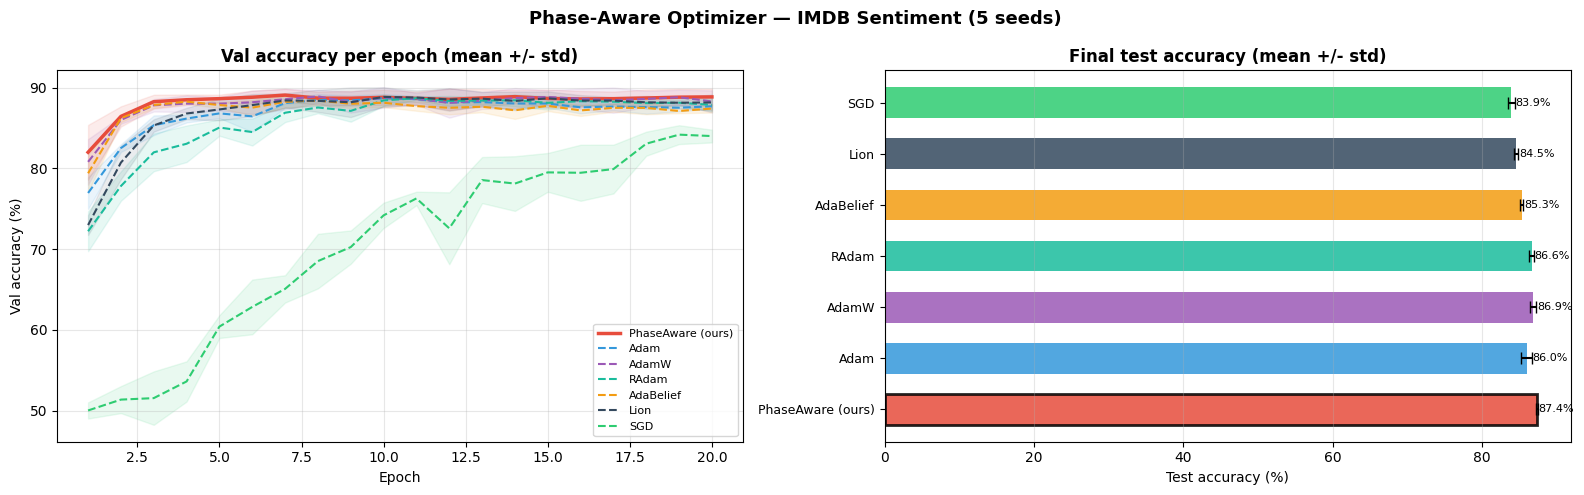

Fig 1 saved: accuracy curves + bar chart


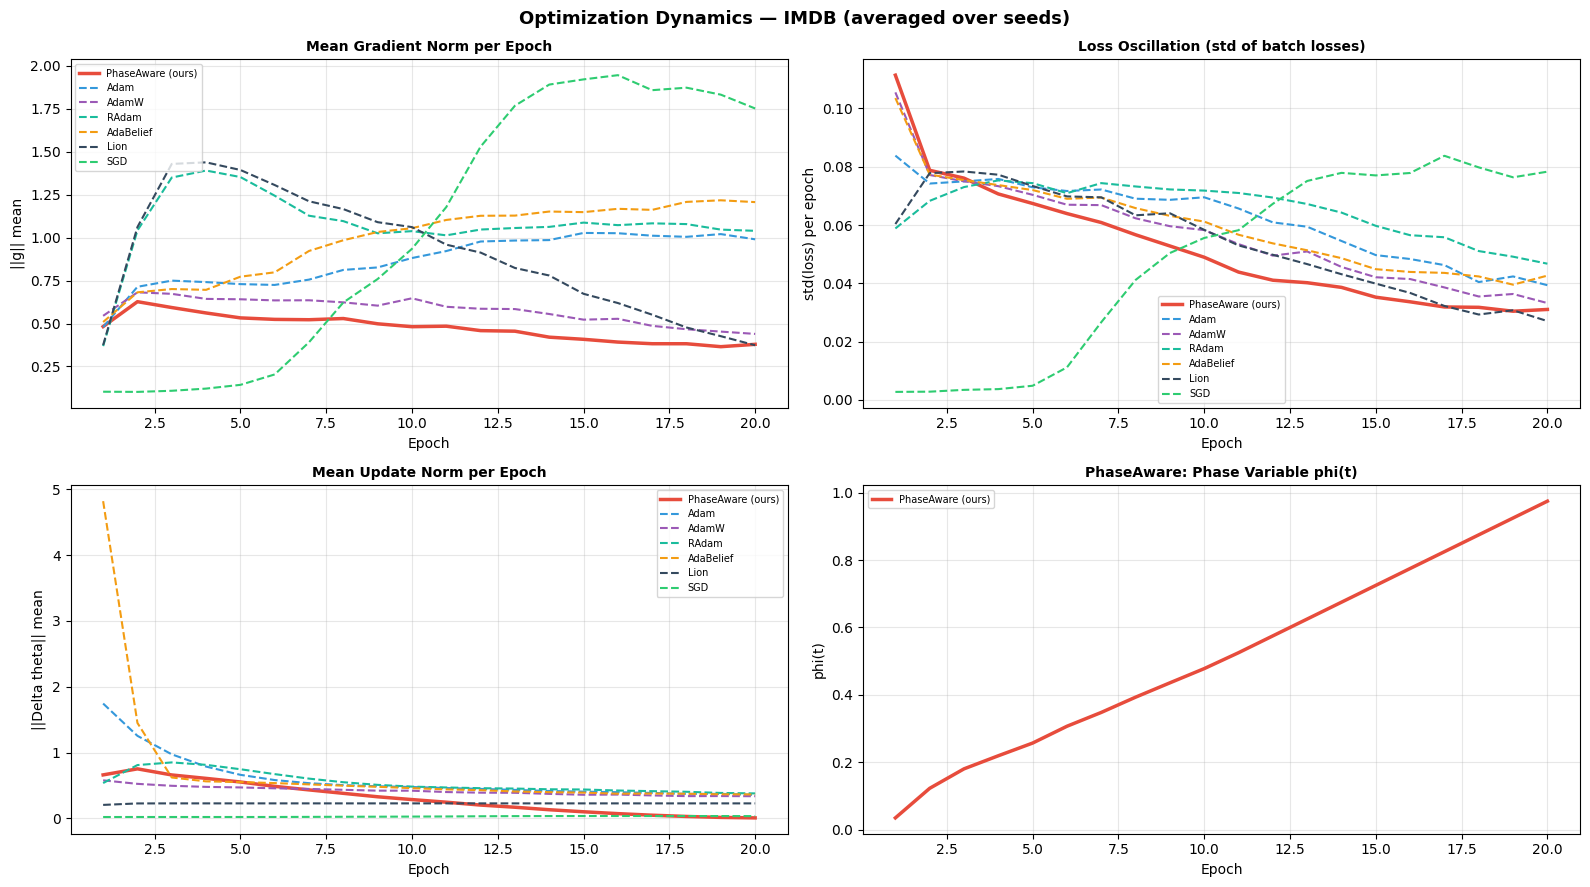

Fig 2 saved: grad norm / loss oscillation / update norm / phase


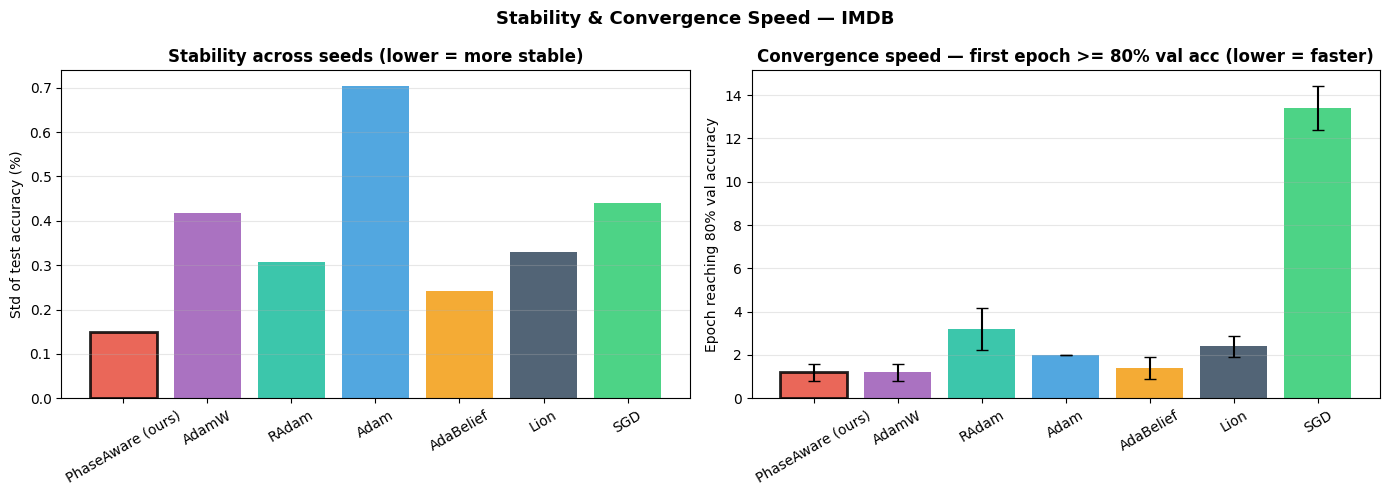

Fig 3 saved: stability (seed std) + convergence speed


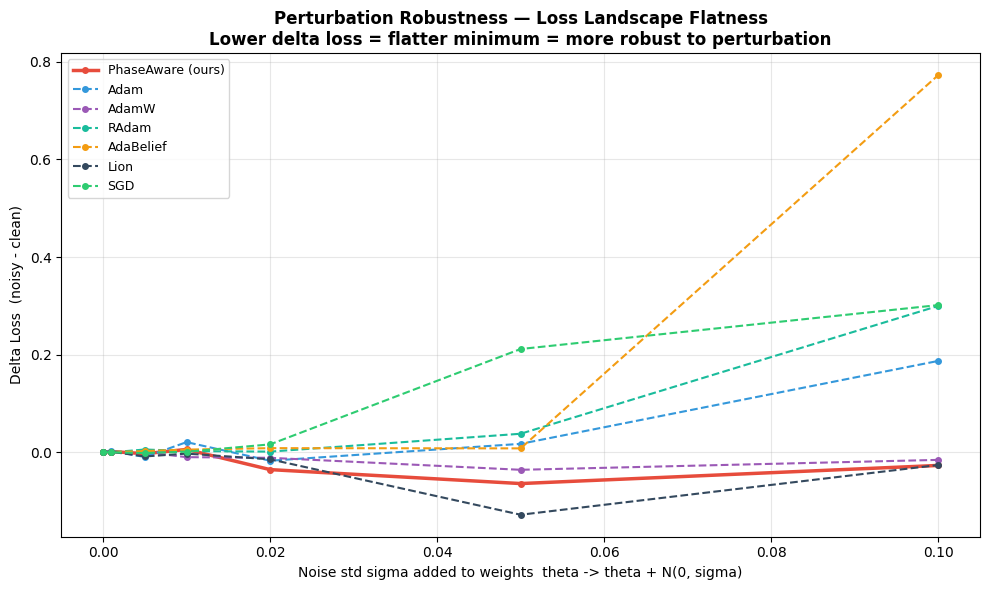

Fig 4 saved: perturbation robustness (loss landscape flatness)


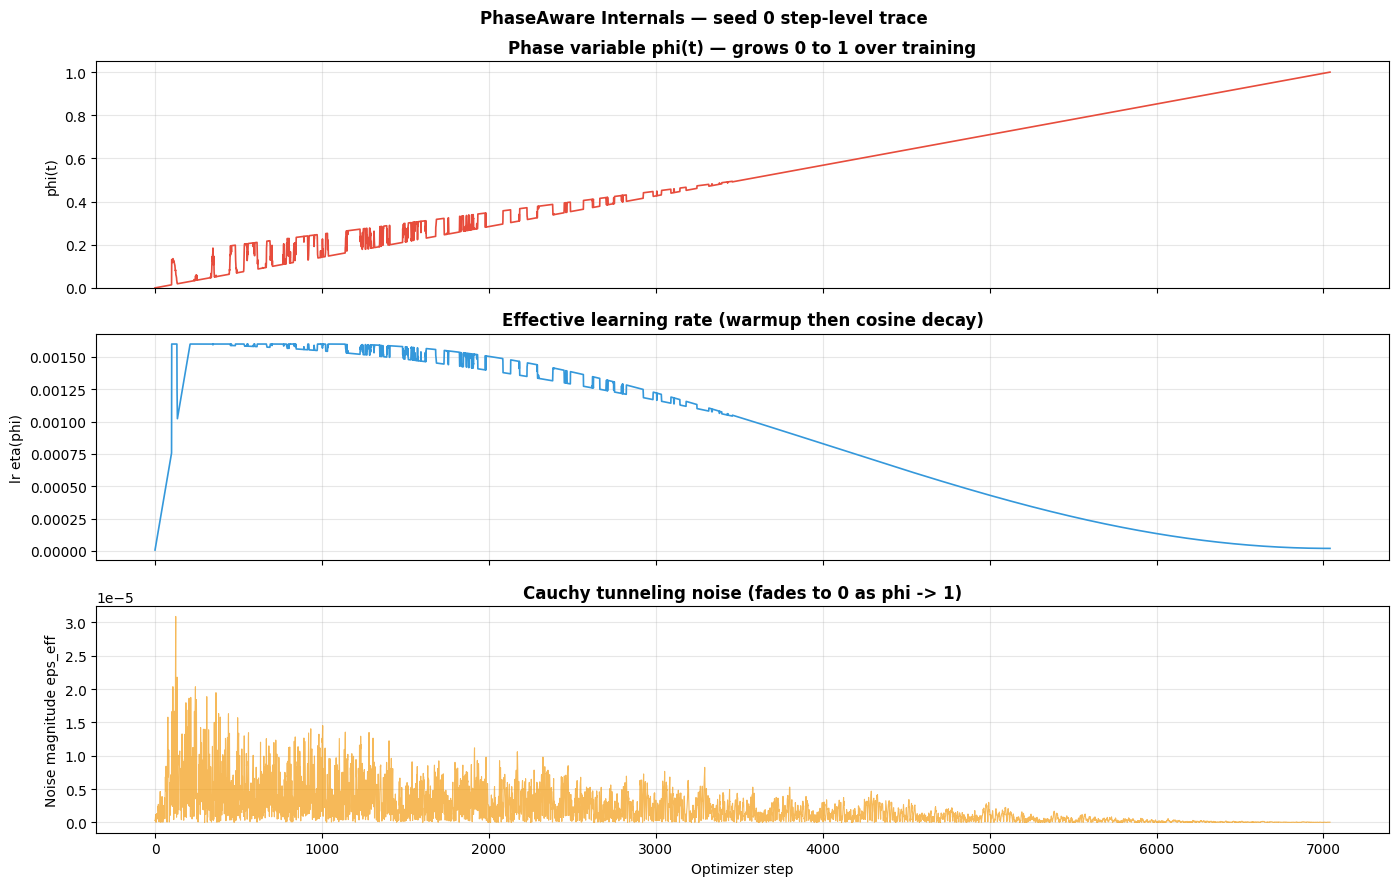

Fig 5 saved: PhaseAware phi / LR / noise step trace

All figures saved to /content/results_imdb_20260418_202248/


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

OPT_COLORS = {
    'phase_aware': '#E74C3C', 'adam': '#3498DB', 'adamw': '#9B59B6',
    'radam': '#1ABC9C', 'adabelief': '#F39C12',
    'lion': '#34495E', 'sgd': '#2ECC71', 'sam': '#E67E22',
}
OPT_LABELS = {
    'phase_aware': 'PhaseAware (ours)', 'adam': 'Adam', 'adamw': 'AdamW',
    'radam': 'RAdam', 'adabelief': 'AdaBelief',
    'lion': 'Lion', 'sgd': 'SGD', 'sam': 'SAM',
}


def _c(n): return OPT_COLORS.get(n, '#888')
def _l(n): return OPT_LABELS.get(n, n)
def _lw(n): return 2.5 if n == 'phase_aware' else 1.5
def _ls(n): return '-' if n == 'phase_aware' else '--'


# ════════════════════════════════════════════════════════════════════════
# FIG 1 — Val accuracy curves + test accuracy bar chart
# ════════════════════════════════════════════════════════════════════════
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(16, 5))
bar_means, bar_stds, bar_cols, bar_lbls = [], [], [], []

for name, runs in all_results.items():
    curves = np.array([r['history']['val_accs'] for r in runs])
    mean, std = curves.mean(0), curves.std(0)
    x = np.arange(1, len(mean)+1)
    ax1a.plot(x, mean, color=_c(name), lw=_lw(name), ls=_ls(name), label=_l(name))
    ax1a.fill_between(x, mean-std, mean+std, color=_c(name), alpha=0.10)
    t_accs = [r['test_acc'] for r in runs]
    bar_means.append(np.mean(t_accs)); bar_stds.append(np.std(t_accs))
    bar_cols.append(_c(name)); bar_lbls.append(_l(name))

ax1a.set_title('Val accuracy per epoch (mean +/- std)', fontweight='bold')
ax1a.set_xlabel('Epoch'); ax1a.set_ylabel('Val accuracy (%)')
ax1a.legend(fontsize=8); ax1a.grid(True, alpha=0.3)

y_pos = np.arange(len(bar_lbls))
bars = ax1b.barh(y_pos, bar_means, xerr=bar_stds, color=bar_cols,
                 alpha=0.85, capsize=4, height=0.6)
for b, lbl in zip(bars, bar_lbls):
    if 'PhaseAware' in lbl:
        b.set_edgecolor('black'); b.set_linewidth(2)
ax1b.set_yticks(y_pos); ax1b.set_yticklabels(bar_lbls, fontsize=9)
ax1b.set_xlabel('Test accuracy (%)')
ax1b.set_title('Final test accuracy (mean +/- std)', fontweight='bold')
ax1b.grid(True, axis='x', alpha=0.3)
for i, (m, s) in enumerate(zip(bar_means, bar_stds)):
    ax1b.text(m+s+0.05, i, f'{m:.1f}%', va='center', fontsize=8)

fig1.suptitle(f'Phase-Aware Optimizer — IMDB Sentiment ({N_SEEDS} seeds)',
              fontsize=13, fontweight='bold')
fig1.tight_layout()
plt.savefig(f'{out_dir}/fig1_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 saved: accuracy curves + bar chart')


# ════════════════════════════════════════════════════════════════════════
# FIG 2 — Optimization Dynamics (4 panels)
#   grad norm | loss oscillation | update norm | phase phi
# ════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 9))
ax_gn, ax_lo, ax_un, ax_ph = axes2.flat

for name in all_results:
    ep = summary[name]['epoch_dynamics']
    x  = np.arange(1, len(ep['grad_norm_mean'])+1)
    ax_gn.plot(x, ep['grad_norm_mean'],  color=_c(name), lw=_lw(name), ls=_ls(name), label=_l(name))
    ax_lo.plot(x, ep['loss_oscillation'],color=_c(name), lw=_lw(name), ls=_ls(name), label=_l(name))
    ax_un.plot(x, ep['update_norm_mean'],color=_c(name), lw=_lw(name), ls=_ls(name), label=_l(name))
    if name == 'phase_aware':
        ph = ep.get('phase_mean', [])
        if ph:
            ax_ph.plot(np.arange(1, len(ph)+1), ph, color=_c(name), lw=2.5, label=_l(name))

for ax, title, ylabel in [
    (ax_gn, 'Mean Gradient Norm per Epoch',          '||g|| mean'),
    (ax_lo, 'Loss Oscillation (std of batch losses)', 'std(loss) per epoch'),
    (ax_un, 'Mean Update Norm per Epoch',             '||Delta theta|| mean'),
    (ax_ph, 'PhaseAware: Phase Variable phi(t)',      'phi(t)'),
]:
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

fig2.suptitle('Optimization Dynamics — IMDB (averaged over seeds)',
              fontsize=13, fontweight='bold')
fig2.tight_layout()
plt.savefig(f'{out_dir}/fig2_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 saved: grad norm / loss oscillation / update norm / phase')


# ════════════════════════════════════════════════════════════════════════
# FIG 3 — Stability across seeds + Convergence speed
# ════════════════════════════════════════════════════════════════════════
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 5))
names_s = sorted(summary, key=lambda n: -summary[n]['test_mean'])
stds_s  = [summary[n]['test_std']      for n in names_s]
conv_m  = [summary[n]['conv_ep_mean']  for n in names_s]
conv_e  = [summary[n]['conv_ep_std']   for n in names_s]
cols_s  = [_c(n) for n in names_s]
lbls_s  = [_l(n) for n in names_s]

bars3a = ax3a.bar(lbls_s, stds_s, color=cols_s, alpha=0.85)
for b, n in zip(bars3a, names_s):
    if n == 'phase_aware': b.set_edgecolor('black'); b.set_linewidth(2)
ax3a.set_ylabel('Std of test accuracy (%)')
ax3a.set_title('Stability across seeds (lower = more stable)', fontweight='bold')
ax3a.tick_params(axis='x', rotation=30); ax3a.grid(True, axis='y', alpha=0.3)

bars3b = ax3b.bar(lbls_s, conv_m, yerr=conv_e, color=cols_s, alpha=0.85, capsize=4)
for b, n in zip(bars3b, names_s):
    if n == 'phase_aware': b.set_edgecolor('black'); b.set_linewidth(2)
ax3b.set_ylabel('Epoch reaching 80% val accuracy')
ax3b.set_title('Convergence speed — first epoch >= 80% val acc (lower = faster)',
               fontweight='bold')
ax3b.tick_params(axis='x', rotation=30); ax3b.grid(True, axis='y', alpha=0.3)

fig3.suptitle('Stability & Convergence Speed — IMDB', fontsize=13, fontweight='bold')
fig3.tight_layout()
plt.savefig(f'{out_dir}/fig3_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3 saved: stability (seed std) + convergence speed')


# ════════════════════════════════════════════════════════════════════════
# FIG 4 — Perturbation Robustness (loss landscape flatness)
# ════════════════════════════════════════════════════════════════════════
fig4, ax4 = plt.subplots(figsize=(10, 6))
for name, pres in perturb_results.items():
    sigmas = sorted(pres.keys())
    deltas = [pres[s] for s in sigmas]
    ax4.plot(sigmas, deltas, color=_c(name), lw=_lw(name), ls=_ls(name),
             marker='o', ms=4, label=_l(name))
ax4.set_xlabel('Noise std sigma added to weights  theta -> theta + N(0, sigma)')
ax4.set_ylabel('Delta Loss  (noisy - clean)')
ax4.set_title('Perturbation Robustness — Loss Landscape Flatness\n'
              'Lower delta loss = flatter minimum = more robust to perturbation',
              fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)
fig4.tight_layout()
plt.savefig(f'{out_dir}/fig4_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 4 saved: perturbation robustness (loss landscape flatness)')


# ════════════════════════════════════════════════════════════════════════
# FIG 5 — PhaseAware internals: phi, LR, noise over every step (seed 0)
# ════════════════════════════════════════════════════════════════════════
if 'phase_aware' in all_results and all_results['phase_aware']:
    pa_logger = all_results['phase_aware'][0]['logger']
    steps_data = pa_logger.steps
    if steps_data:
        fig5, axes5 = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
        ax5a, ax5b, ax5c = axes5
        xs = np.arange(len(steps_data))
        phases = [s['phase'] for s in steps_data]
        lrs    = [s['lr']    for s in steps_data]
        noises = [s['noise_magnitude'] for s in steps_data]
        ax5a.plot(xs, phases, color='#E74C3C', lw=1.2)
        ax5a.set_ylabel('phi(t)'); ax5a.set_ylim(0, 1.05)
        ax5a.set_title('Phase variable phi(t) — grows 0 to 1 over training',
                       fontweight='bold')
        ax5a.grid(True, alpha=0.3)
        ax5b.plot(xs, lrs, color='#3498DB', lw=1.2)
        ax5b.set_ylabel('lr eta(phi)')
        ax5b.set_title('Effective learning rate (warmup then cosine decay)',
                       fontweight='bold')
        ax5b.grid(True, alpha=0.3)
        ax5c.plot(xs, noises, color='#F39C12', lw=0.8, alpha=0.7)
        ax5c.set_ylabel('Noise magnitude eps_eff')
        ax5c.set_xlabel('Optimizer step')
        ax5c.set_title('Cauchy tunneling noise (fades to 0 as phi -> 1)',
                       fontweight='bold')
        ax5c.grid(True, alpha=0.3)
        fig5.suptitle('PhaseAware Internals — seed 0 step-level trace',
                      fontsize=12, fontweight='bold')
        fig5.tight_layout()
        plt.savefig(f'{out_dir}/fig5_phaseaware_trace.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Fig 5 saved: PhaseAware phi / LR / noise step trace')

print(f'\nAll figures saved to {out_dir}/')


## Statistical Analysis — Welch's t-test + Full Dynamics Table


In [ ]:
from scipy import stats as scipy_stats

if 'phase_aware' not in all_results:
    print('Run the experiment first (cell above).')
else:
    pa_test = np.array([r['test_acc'] for r in all_results['phase_aware']])
    print(f"PhaseAware  test: mean={pa_test.mean():.3f}%  std={pa_test.std():.3f}%  n={len(pa_test)}")
    print()
    print(f"  {'Baseline':14}  {'Delta test':>10}  {'t-stat':>8}  {'p-value':>10}  {'sig':>5}  95% CI")
    print(f"  {'-'*72}")
    for name, runs in sorted(all_results.items(),
                             key=lambda x: -np.mean([r['test_acc'] for r in x[1]])):
        if name == 'phase_aware':
            continue
        base  = np.array([r['test_acc'] for r in runs])
        t, p  = scipy_stats.ttest_ind(pa_test, base, equal_var=False)
        delta = pa_test.mean() - base.mean()
        se    = np.sqrt(pa_test.var(ddof=1)/len(pa_test) + base.var(ddof=1)/len(base))
        df_n  = se**4
        df_d  = ((pa_test.var(ddof=1)/len(pa_test))**2/(len(pa_test)-1) +
                 (base.var(ddof=1)/len(base))**2/(len(base)-1))
        ci    = scipy_stats.t.ppf(0.975, df_n/df_d) * se
        sig   = '***' if p < 0.001 else ('** ' if p < 0.01 else ('*  ' if p < 0.05 else 'ns '))
        print(f"  {name:14}  {delta:+9.3f}%  {t:8.3f}  {p:10.4f}  {sig:>5}  [{delta-ci:+.3f}, {delta+ci:+.3f}]")
    print()
    print('  *** p<0.001  ** p<0.01  * p<0.05  ns not significant')
    print('  Positive delta = PhaseAware beats the baseline')

    # ── Full dynamics comparison table ─────────────────────────────────────
    print()
    print('=' * 100)
    print('FULL OPTIMIZER COMPARISON — accuracy + dynamics + landscape')
    print('=' * 100)
    hdr = (f"  {'Optimizer':14}  {'Test acc':>12}  {'Seed std':>9}  "
           f"{'Conv ep':>8}  {'Grad norm':>10}  {'Loss osc':>9}  "
           f"{'Upd norm':>9}  {'Perturb 0.01':>13}")
    print(hdr)
    print('  ' + '-'*98)
    for name in sorted(summary, key=lambda n: -summary[n]['test_mean']):
        s   = summary[name]
        ep  = s['epoch_dynamics']
        gn  = float(np.mean(ep['grad_norm_mean']))   if ep['grad_norm_mean']   else float('nan')
        lo  = float(np.mean(ep['loss_oscillation'])) if ep['loss_oscillation'] else float('nan')
        un  = float(np.mean(ep['update_norm_mean'])) if ep['update_norm_mean'] else float('nan')
        pr  = s['perturbation'].get('0.01', float('nan'))
        mrk = ' <-- PhaseAware' if name == 'phase_aware' else ''
        print(f"  {name:14}  "
              f"{s['test_mean']:6.2f}+/-{s['test_std']:.2f}%  "
              f"{s['test_std']:8.3f}%  "
              f"{s['conv_ep_mean']:7.1f}ep  "
              f"{gn:9.4f}  "
              f"{lo:8.4f}  "
              f"{un:8.4f}  "
              f"{pr:12.4f}{mrk}")
    print()
    print('  Seed std    = std of test accuracy across seeds (lower = more stable)')
    print('  Conv ep     = first epoch reaching 80% val acc (lower = faster)')
    print('  Grad norm   = mean ||g|| across all training steps')
    print('  Loss osc    = mean std of batch losses per epoch (lower = smoother)')
    print('  Upd norm    = mean ||Delta theta|| per step (exploration size)')
    print('  Perturb 0.01= delta loss at sigma=0.01 weight noise (lower = flatter minimum)')


PhaseAware  test: mean=87.368%  std=0.148%  n=5

  Baseline        Delta test    t-stat     p-value    sig  95% CI
  ------------------------------------------------------------------------
  adamw              +0.512%     2.311      0.0689    ns   [-0.058, +1.082]
  radam              +0.729%     4.262      0.0058    **   [+0.306, +1.151]
  adam               +1.406%     3.908      0.0148    *    [+0.438, +2.373]
  adabelief          +2.071%    14.635      0.0000    ***  [+1.733, +2.409]
  lion               +2.832%    15.651      0.0000    ***  [+2.380, +3.284]
  sgd                +3.455%    14.863      0.0000    ***  [+2.854, +4.057]

  *** p<0.001  ** p<0.01  * p<0.05  ns not significant
  Positive delta = PhaseAware beats the baseline

FULL OPTIMIZER COMPARISON — accuracy + dynamics + landscape
  Optimizer           Test acc   Seed std   Conv ep   Grad norm   Loss osc   Upd norm   Perturb 0.01
  -------------------------------------------------------------------------------------